# ***Cell 1 Imports & Output Directory***

In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

OUTPUT_DIR = "/content/Week_2_Package"
VIS_DIR = os.path.join(OUTPUT_DIR, "visualizations")

os.makedirs(VIS_DIR, exist_ok=True)

# ***Cell 2 Fetch Dataset from Drive***

In [ ]:
from google.colab import drive
import glob, zipfile

drive.mount("/content/drive")

zip_matches = glob.glob("/content/drive/MyDrive/**/cleaned_dataset.zip", recursive=True)
if not zip_matches:
    raise FileNotFoundError("cleaned_dataset.zip not found in Drive")

with zipfile.ZipFile(zip_matches[0], "r") as zf:
    zf.extractall("/content")

print(f"Extracted: {zip_matches[0]}")

Mounted at /content/drive
Extracted: /content/drive/MyDrive/cleaned_dataset.zip


# ***Cell 3 Load metadata.csv***

In [ ]:
import os

meta_files = []

for root, dirs, files_ in os.walk("/content"):
    for file in files_:
        if file.lower() == "metadata.csv":
            meta_files.append(os.path.join(root, file))

print("Found metadata files:")

for path in meta_files:
    print(path)

Found metadata files:
/content/cleaned_dataset/metadata.csv
/content/drive/MyDrive/cleaned_dataset/metadata.csv


In [ ]:
import pandas as pd

meta_path = "/content/cleaned_dataset/metadata.csv"

df = pd.read_csv(meta_path)

print("Metadata path:", meta_path)
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df.head()

Metadata path: /content/cleaned_dataset/metadata.csv
Shape: (7565, 10)
Columns:
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


# ***Cell 4 Capacity Cleaning & Discharge Data***

In [ ]:
df["Capacity"] = pd.to_numeric(
    df["Capacity"].astype(str).str.replace(r"[\[\]]", "", regex=True),
    errors="coerce"
)

dis_df = df[
    (df["type"] == "discharge") &
    (df["Capacity"] > 0.05)
].copy()

print(f"Discharge samples: {len(dis_df)}")
print(f"Batteries: {dis_df['battery_id'].nunique()}")

Discharge samples: 2714
Batteries: 34


# ***Cell 5 Initial Capacity & SOH Calculation***

In [ ]:
c0 = dis_df.groupby("battery_id")["Capacity"].first()

dis_df["initial_capacity"] = dis_df["battery_id"].map(c0)
dis_df["SOH"] = dis_df["Capacity"] / dis_df["initial_capacity"]

dis_df[["battery_id", "test_id", "Capacity", "initial_capacity", "SOH"]].head()

,battery_id,test_id,Capacity,initial_capacity,SOH
0,B0047,0,1.674305,1.674305,1.000000
4,B0047,4,1.524366,1.674305,0.910447
6,B0047,6,1.508076,1.674305,0.900718
8,B0047,8,1.483558,1.674305,0.886074
10,B0047,10,1.467139,1.674305,0.876268


# ***Cell 6 Basic SOH Statistics***

In [ ]:
print("SOH Statistics")
print(dis_df["SOH"].describe())

print("\nSOH by Battery")
print(
    dis_df.groupby("battery_id")["SOH"]
    .agg(["min", "max", "mean", "count"])
)

SOH Statistics
count    2714.000000
mean        2.824811
std         5.550812
min         0.032681
25%         0.803241
50%         0.989204
75%         1.657102
max        27.550168
Name: SOH, dtype: float64

SOH by Battery
                 min        max       mean  count
battery_id                                       
B0005       0.693488   1.000000   0.847031    168
B0006       0.566893   1.000000   0.759997    168
B0007       0.740569   1.000000   0.869580    168
B0018       0.722937   1.000000   0.839729    132
B0025       0.957108   1.001068   0.983487     28
B0026       0.764559   1.001807   0.979421     28
B0027       0.970814   1.000000   0.989896     28
B0028       0.951542   1.000055   0.980813     28
B0029       0.949675   1.086712   1.016792     40
B0030       0.943668   1.075772   1.003006     40
B0031       1.000000   1.099709   1.045908     40
B0032       0.959490   1.110958   1.029146     40
B0033       1.000000  27.550168  20.599125    197
B0034       1.000000   2.

# ***Cell 7 Degradation Trajectory Visualization***

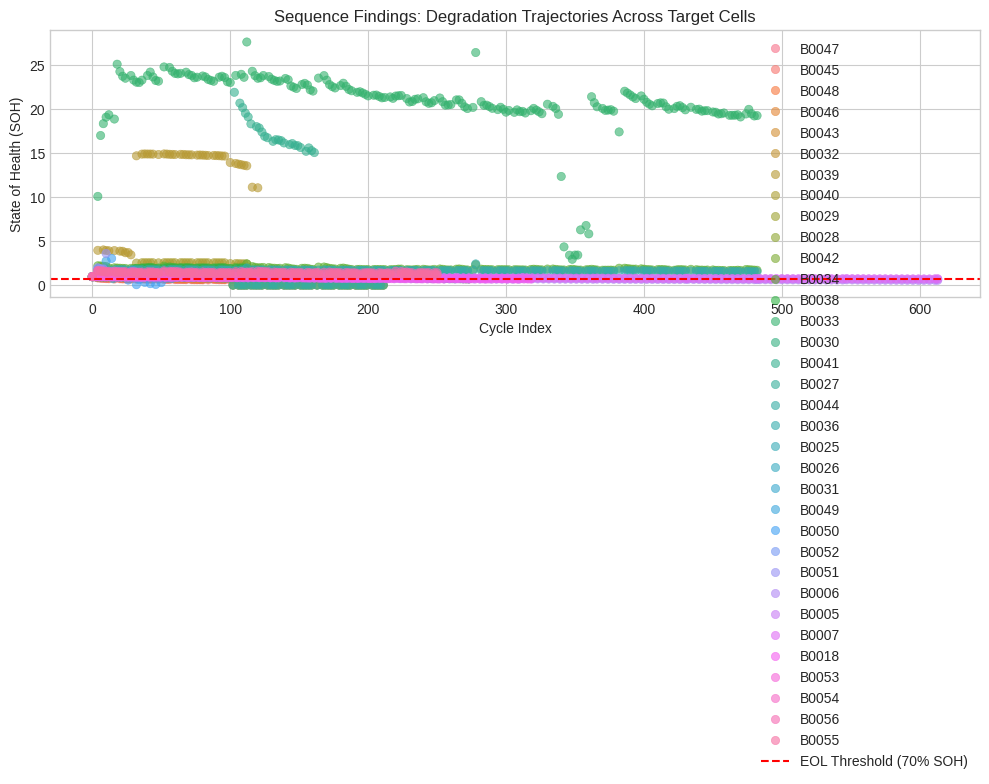

In [ ]:
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=dis_df,
    x="test_id",
    y="SOH",
    hue="battery_id",
    alpha=0.6,
    edgecolor=None
)

plt.axhline(
    0.70,
    color="red",
    linestyle="--",
    label="EOL Threshold (70% SOH)"
)

plt.title("Sequence Findings: Degradation Trajectories Across Target Cells")
plt.xlabel("Cycle Index")
plt.ylabel("State of Health (SOH)")
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(VIS_DIR, "sequence_degradation_findings.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ***Cell 8 Degradation Stage Distribution***

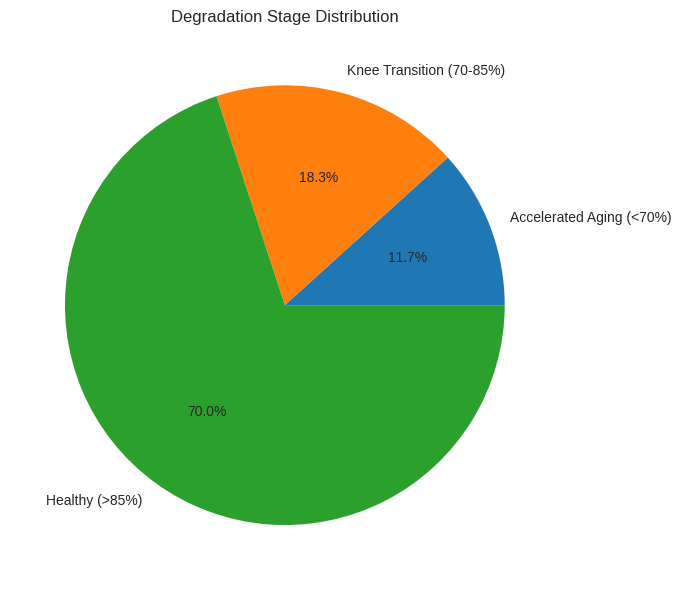

In [ ]:
bins = [-np.inf, 0.70, 0.85, np.inf]

labels = [
    "Accelerated Aging (<70%)",
    "Knee Transition (70-85%)",
    "Healthy (>85%)"
]

stage_counts = (
    pd.cut(
        dis_df["SOH"],
        bins=bins,
        labels=labels
    )
    .value_counts()
    .reindex(labels)
)

plt.figure(figsize=(8, 6))

plt.pie(
    stage_counts,
    labels=stage_counts.index,
    autopct="%1.1f%%"
)

plt.title("Degradation Stage Distribution")
plt.tight_layout()

plt.savefig(
    os.path.join(VIS_DIR, "degradation_stages.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ***Cell 9 Check Generated Package***

In [ ]:
for root, dirs, files_ in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files_:
        print(f"{indent}  {file}")

Week_2_Package/
  visualizations/
    degradation_stages.png
    sequence_degradation_findings.png


# ***Cell 10 Create ZIP***

In [ ]:
zip_path = shutil.make_archive(
    "/content/Week_2_Package",
    "zip",
    OUTPUT_DIR
)

print(f"Package created: {zip_path}")

Package created: /content/Week_2_Package.zip


# ***Cell 11 Download***

In [ ]:
files.download("/content/Week_2_Package.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>